In [1]:
#Importar librerias
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import sys
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
import community.community_louvain as cl
import pandas as pd
import pickle

from utils import *

In [2]:
#Importar datos
filename = 'email-Eu-core.txt'
df_mails = pd.read_csv(filename, sep=' ', header=None)
df_mails.head()

,0,1
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


In [3]:
G_mails = nx.from_pandas_edgelist(df_mails, source=0, target=1, create_using=nx.DiGraph())

In [4]:
#Generar grafo: componente fuertemente conexa más grande, sin autoenlaces
G = G_mails.copy()
G.remove_edges_from(nx.selfloop_edges(G))
largest_scc = max(nx.strongly_connected_components(G), key=len)
G = G.subgraph(largest_scc).copy()

In [5]:
def edge_removal_fixed(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            largest_cc = max(nx.strongly_connected_components(G), key=len)
            sizes.append(len(largest_cc) / N)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)

    sizes.append(0)
    return np.array(sizes)

In [6]:
def average_random(G, centrality_dict, n_iter=100):
    curves = [edge_removal_fixed(G, centrality_dict, 'random') for _ in range(n_iter)]
    return np.mean(curves, axis=0)

In [7]:
# calcular centralidades
b_centrality = nx.betweenness_centrality(G)
d_centrality = nx.degree_centrality(G)
#i_centrality = dict(G.in_degree())
#p_centrality = nx.pagerank(G)
#c_centrality = nx.closeness_centrality(G)
#e_centrality = nx.eigenvector_centrality(G)

centralities = {
    'Intermediación': b_centrality,
    'Grado': d_centrality,
    #'Grado-Out': o_centrality,
    #'Grado-In': i_centrality,
    #'PageRank': p_centrality,
    #'Cercanía': c_centrality,
    #'Autovector': e_centrality
}

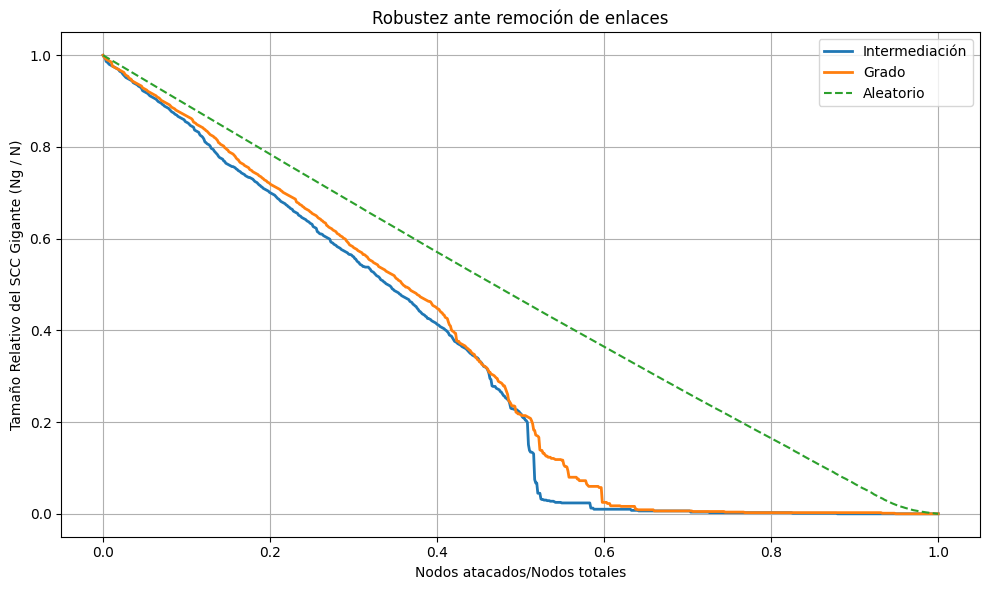

In [8]:
N = G.number_of_nodes()
x = np.arange(N + 1) / N
curves = {}

plt.figure(figsize=(10, 6))
for name, centrality in centralities.items():
    curves[f'curve_{name}'] = edge_removal_fixed(G, centrality, strategy='targeted')
    plt.plot(x, curves[f'curve_{name}'], label=f'{name}', linewidth=2)

curve_random = average_random(G, centrality)
plt.plot(x, curve_random, label='Aleatorio', linestyle='--')
plt.xlabel('Nodos atacados/Nodos totales')
plt.ylabel('Tamaño Relativo del SCC Gigante (Ng / N)')
plt.title('Robustez ante remoción de enlaces')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [9]:
in_deg = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])

print("mean in:", in_deg.mean()/N)
print("mean out:", out_deg.mean()/N)

mean in: 0.037434341021915014
mean out: 0.037434341021915014


In [10]:
nx.degree_assortativity_coefficient(G)

-0.009840633753895045

In [11]:
print(np.corrcoef(in_deg, out_deg)[0,1])

0.9223323778385025


In [12]:
#Cálculo de área bajo la curva para cada centralidad
areas = {name: np.trapz(curve, x) for name, curve in curves.items()}
areas['Aleatorio'] = np.trapz(curve_random, x)
areas


C:\Users\Home\AppData\Local\Temp\ipykernel_9956\3695750620.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  areas = {name: np.trapz(curve, x) for name, curve in curves.items()}
C:\Users\Home\AppData\Local\Temp\ipykernel_9956\3695750620.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  areas['Aleatorio'] = np.trapz(curve_random, x)


{'curve_Intermediación': np.float64(0.31914024152888687),
 'curve_Grado': np.float64(0.33567537053608126),
 'Aleatorio': np.float64(0.47386277176652314)}

In [13]:
#area sobre N
areas_normalized = {name: area / N for name, area in areas.items()}
areas_normalized

{'curve_Intermediación': np.float64(0.0003974349209575179),
 'curve_Grado': np.float64(0.0004180266133699642),
 'Aleatorio': np.float64(0.0005901155314651595)}

In [14]:
def random_attack_curve(G_original, step=1, n_sim=100):
    N = G_original.number_of_nodes()
    curves = []

    for _ in range(n_sim):
        G = G_original.copy()
        nodes = list(G.nodes())
        np.random.shuffle(nodes)

        scc_sizes = []

        for i in range(0, len(nodes), step):

            attacked = nodes[i:i+step]

            for node in attacked:
                if node in G:
                    G.remove_edges_from(
                        list(G.in_edges(node)) +
                        list(G.out_edges(node))
                    )

            if G.number_of_nodes() > 0:
                largest = max(
                    nx.strongly_connected_components(G),
                    key=len
                )
                scc_sizes.append(len(largest)/N)

        curves.append(scc_sizes)

    min_len = min(len(c) for c in curves)
    curves = np.array([c[:min_len] for c in curves])

    mean = curves.mean(axis=0)
    std = curves.std(axis=0)

    x = np.arange(min_len)*step/N

    return x, mean, std

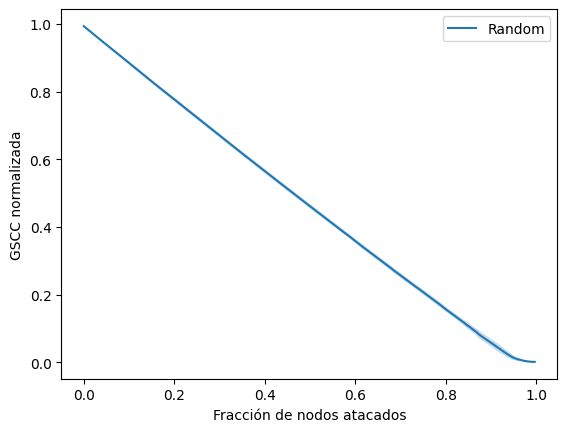

In [15]:
x, mean, std = random_attack_curve(G, step=5, n_sim=100)

plt.plot(x, mean, label='Random')
plt.fill_between(
    x,
    mean-std,
    mean+std,
    alpha=0.25
)

plt.xlabel('Fracción de nodos atacados')
plt.ylabel('GSCC normalizada')
plt.legend()
plt.show()

In [16]:
def fragment_size_distribution(G_original, ranking):

    G = G_original.copy()
    all_sizes = []

    for node in ranking:

        G.remove_edges_from(
            list(G.in_edges(node)) + list(G.out_edges(node))
        )

        sccs = sorted(
            [len(c) for c in nx.strongly_connected_components(G)],
            reverse=True
        )

        all_sizes.append(sccs)

    return all_sizes

In [17]:
degree_ranking = sorted(
    centralities['Grado'],
    key=centralities['Grado'].get,
    reverse=True
)

In [18]:
dist = fragment_size_distribution(
    G,
    degree_ranking
)

In [19]:
def plot_fragment_histograms(all_sizes):

    steps = [
        int(0.1 * len(all_sizes)),
        int(0.3 * len(all_sizes)),
        int(0.5 * len(all_sizes)),
        int(0.7 * len(all_sizes))
    ]

    plt.figure(figsize=(12,8))

    for i, step in enumerate(steps, 1):

        plt.subplot(2,2,i)

        plt.hist(
            all_sizes[step],
            bins=20
        )

        plt.title(f"{100*step/len(all_sizes):.0f}% removido")

        plt.xlabel("Tamaño SCC")
        plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

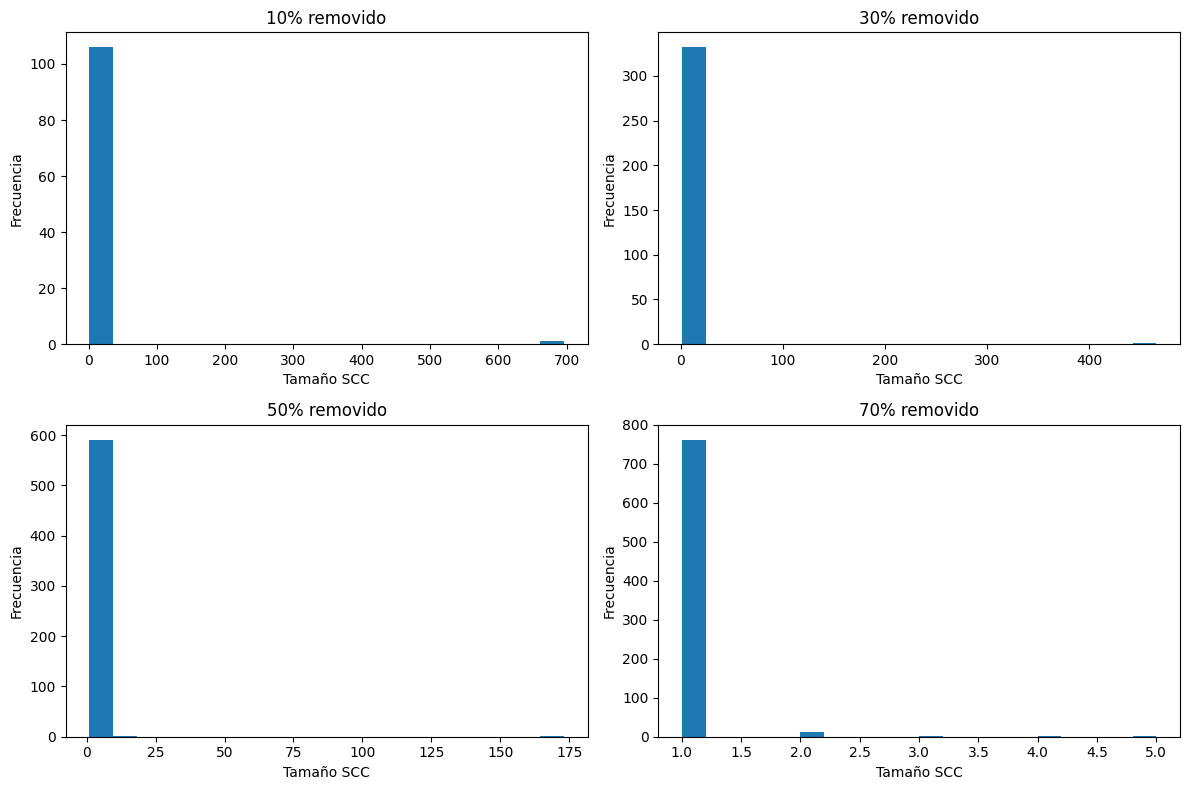

In [20]:
plot_fragment_histograms(dist)

In [21]:
def strong_vs_weak_curve(G_original, centrality_dict):

    G = G_original.copy()
    N = G.number_of_nodes()

    ordered = sorted(
        centrality_dict,
        key=centrality_dict.get,
        reverse=True
    )

    strong = []
    weak = []
    x = []

    for i,node in enumerate(ordered):

        if node in G:
            G.remove_edges_from(
                list(G.in_edges(node)) +
                list(G.out_edges(node))
            )

        scc = max(
            nx.strongly_connected_components(G),
            key=len
        )

        wcc = max(
            nx.weakly_connected_components(G),
            key=len
        )

        strong.append(len(scc)/N)
        weak.append(len(wcc)/N)

        x.append(i/N)

    return x,strong,weak

In [22]:
x, s, w = strong_vs_weak_curve(
    G,
    centralities['Grado']
)

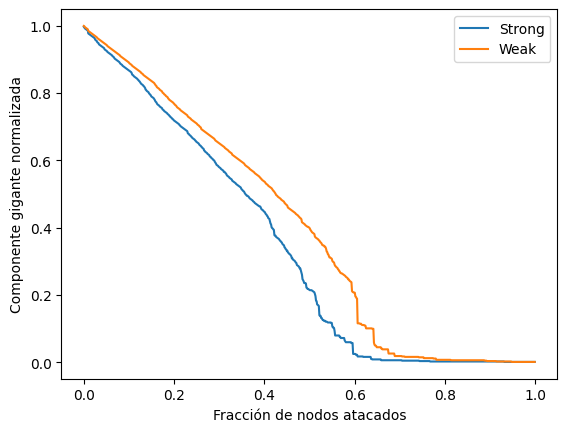

In [23]:
plt.plot(x, s, label='Strong')
plt.plot(x, w, label='Weak')

plt.xlabel('Fracción de nodos atacados')
plt.ylabel('Componente gigante normalizada')

plt.legend()
plt.show()

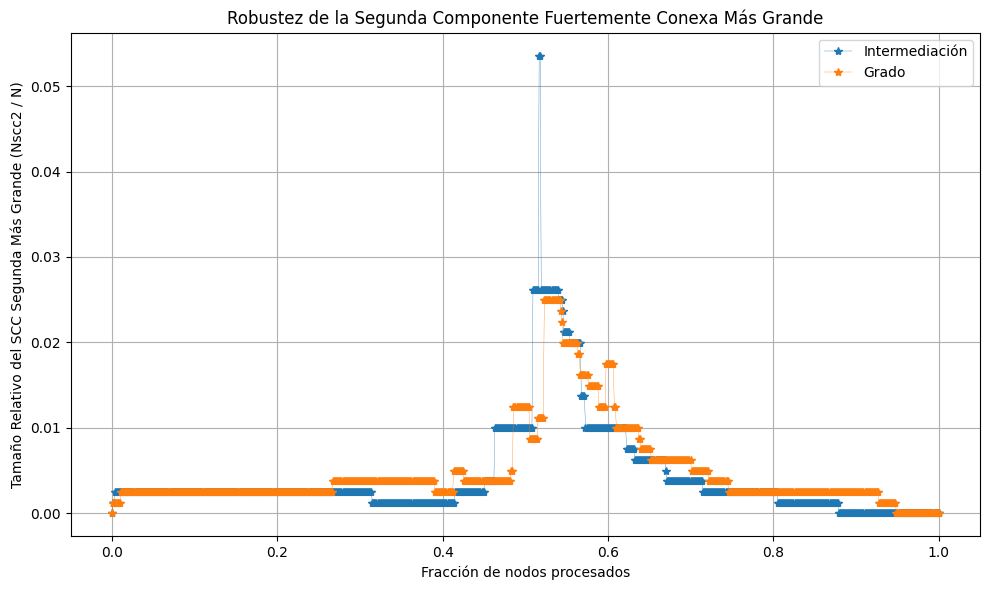

In [24]:
#Análisis de robustez de segunda componente fuertemente conexa más grande
def edge_removal_fixed_second_largest(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    x = np.arange(N + 1) / N
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
            if len(sccs) > 1:
                second_largest_cc = sccs[1]
                sizes.append(len(second_largest_cc) / N)
            else:
                sizes.append(0)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)

    sizes.append(0)
    return np.array(sizes)

N = G.number_of_nodes()
x = np.arange(N + 1) / N

curves_second = {}
plt.figure(figsize=(10, 6))

for name, centrality in centralities.items():
    # La función devuelve un array de tamaño N + 1 (238 elementos)
    curves_second[f'curve_{name}'] = edge_removal_fixed_second_largest(G, centrality, strategy='targeted')
    
    # Ahora x (238) y la curva (238) coinciden perfectamente
    plt.plot(x, curves_second[f'curve_{name}'], label=f'{name}', marker='*', linewidth=0.25)

# Configuración de la gráfica
plt.xlabel('Fracción de nodos procesados')
plt.ylabel('Tamaño Relativo del SCC Segunda Más Grande (Nscc2 / N)')
plt.title('Robustez de la Segunda Componente Fuertemente Conexa Más Grande')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

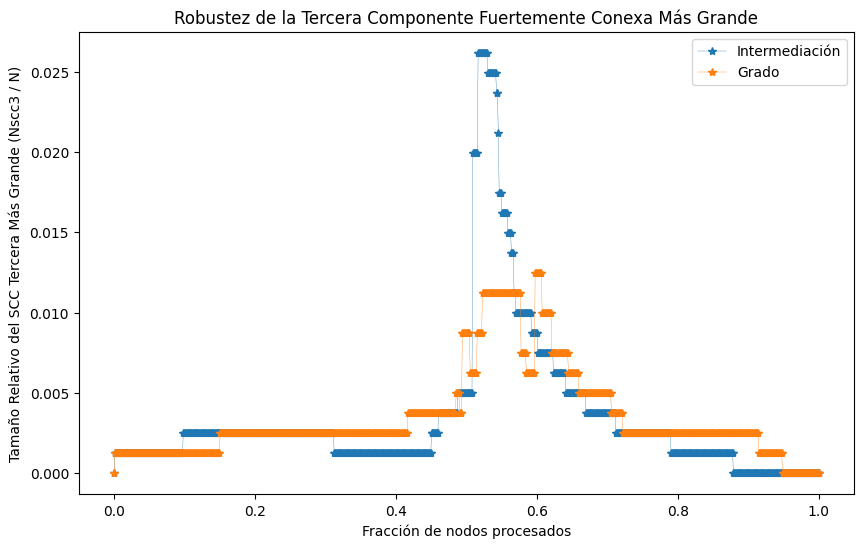

In [25]:
#Análisis de robustez de tercera componente fuertemente conexa más grande
def edge_removal_fixed_third_largest(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
            if len(sccs) > 2:
                third_largest_cc = sccs[2]
                sizes.append(len(third_largest_cc) / N)
            else:
                sizes.append(0)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)
    sizes.append(0)
    return np.array(sizes)
curves_third = {}
plt.figure(figsize=(10, 6))
for name, centrality in centralities.items():
    curves_third[f'curve_{name}'] = edge_removal_fixed_third_largest(G, centrality, strategy='targeted')
    plt.plot(x, curves_third[f'curve_{name}'], label=f'{name}', marker='*', linewidth=0.25)
#curve_random_third = average_random(G, centrality, n_iter=20)
#plt.plot(x, curve_random_third, label='Aleatorio', linestyle='--')
plt.xlabel('Fracción de nodos procesados')
plt.ylabel('Tamaño Relativo del SCC Tercera Más Grande (Nscc3 / N)')
plt.title('Robustez de la Tercera Componente Fuertemente Conexa Más Grande')
plt.legend()

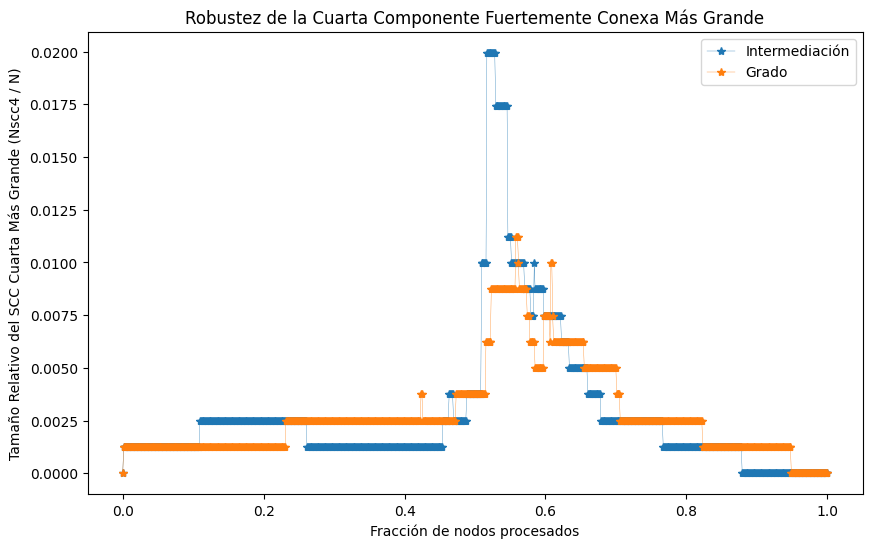

In [26]:
##Análisis de robustez de cuarta componente fuertemente conexa más grande
def edge_removal_fixed_fourth_largest(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
            if len(sccs) > 3:
                fourth_largest_cc = sccs[3]
                sizes.append(len(fourth_largest_cc) / N)
            else:
                sizes.append(0)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)
    sizes.append(0)
    return np.array(sizes)
curves_fourth = {}
plt.figure(figsize=(10, 6))
for name, centrality in centralities.items():
    curves_fourth[f'curve_{name}'] = edge_removal_fixed_fourth_largest(G, centrality, strategy='targeted')
    plt.plot(x, curves_fourth[f'curve_{name}'], label=f'{name}', marker='*', linewidth=0.25)
#curve_random_fourth = average_random(G, centrality, n_iter=20)
#plt.plot(x, curve_random_fourth, label='Aleatorio', linestyle='--')    
plt.xlabel('Fracción de nodos procesados')
plt.ylabel('Tamaño Relativo del SCC Cuarta Más Grande (Nscc4 / N)')
plt.title('Robustez de la Cuarta Componente Fuertemente Conexa Más Grande')
plt.legend()



In [27]:
#Código para armar una tabla por tipo de centralidad. En filas tiene 100 valores de fracción de nodos procesados, y en las columnas tiene el tamaño de la componente fiertemente coneexa más grande, la segunda, la tercera y la cuarta.
table_data = []
for i in range(len(x)//10):
    row = [x[i*10]]
    for name in centralities.keys():
        row.append(curves[f'curve_{name}'][i*10])
        row.append(curves_second[f'curve_{name}'][i*10])
        row.append(curves_third[f'curve_{name}'][i*10])
        row.append(curves_fourth[f'curve_{name}'][i*10])
    table_data.append(row)
columns = ['Fracción de nodos procesados']
for name in centralities.keys():
    columns.extend([f'{name} - SCC1', f'{name} - SCC2', f'{name} - SCC3', f'{name} - SCC4'])
df_results = pd.DataFrame(table_data, columns=columns)
print(df_results.head(50))


    Fracción de nodos procesados  Intermediación - SCC1  \
0                       0.000000               1.000000   
1                       0.012453               0.975093   
2                       0.024907               0.956413   
3                       0.037360               0.938979   
4                       0.049813               0.920299   
5                       0.062267               0.905355   
6                       0.074720               0.887920   
7                       0.087173               0.870486   
8                       0.099626               0.854296   
9                       0.112080               0.834371   
10                      0.124533               0.806974   
11                      0.136986               0.783313   
12                      0.149440               0.762142   
13                      0.161893               0.748443   
14                      0.174346               0.733499   
15                      0.186800               0.717310 

In [28]:
def robustness_fragmentation(
    G,
    centrality=None,
    strategy="targeted",   # "targeted" o "random"
    component_type="strong"  # "strong" o "weak"
):
    G = G.copy()
    N = G.number_of_nodes()
    
    nodes = list(G.nodes())
    
    # Orden de ataque
    if strategy == "targeted":
        assert centrality is not None, "Falta centralidad"
        nodes = sorted(nodes, key=lambda x: centrality[x], reverse=True)
    elif strategy == "random":
        np.random.shuffle(nodes)
    
    # Resultados
    S1 = []
    S2 = []
    mean_rest = []
    n_components = []
    all_sizes = []

    for i, node in enumerate(nodes):
        
        # Elegir tipo de componente
        if component_type == "strong":
            comps = list(nx.strongly_connected_components(G))
        elif component_type == "weak":
            comps = list(nx.weakly_connected_components(G))
        else:
            raise ValueError("component_type debe ser 'strong' o 'weak'")
        
        sizes = sorted([len(c) for c in comps], reverse=True)
        all_sizes.append(sizes)
        
        # Métricas
        s1 = sizes[0] if len(sizes) > 0 else 0
        s2 = sizes[1] if len(sizes) > 1 else 0
        
        S1.append(s1 / N)
        S2.append(s2 / N)
        n_components.append(len(sizes))
        
        if len(sizes) > 1:
            mean_rest.append(np.mean(sizes[1:]) / N)
        else:
            mean_rest.append(0)
        
        # remover nodo
        G.remove_node(node)
    
    f = np.arange(len(S1)) / N  # fracción removida
    
    return {
        "f": f,
        "S1": np.array(S1),
        "S2": np.array(S2),
        "mean_rest": np.array(mean_rest),
        "n_components": np.array(n_components),
        "all_sizes": all_sizes
    }

In [29]:
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

In [30]:
res_deg_strong = robustness_fragmentation(
    G,
    centrality=deg_cent,
    strategy="targeted",
    component_type="strong"
)

In [31]:
res_deg_weak = robustness_fragmentation(
    G,
    centrality=deg_cent,
    strategy="targeted",
    component_type="weak"
)

In [32]:
res_rand_weak = robustness_fragmentation(
    G,
    strategy="random",
    component_type="weak"
)

In [33]:
def plot_S1_S2(res, title=""):
    plt.figure(figsize=(6,4))
    plt.plot(res["f"], res["S1"], label="S1 (GCC)")
    plt.plot(res["f"], res["S2"], label="S2")
    plt.xlabel("Fracción removida")
    plt.ylabel("Tamaño relativo")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

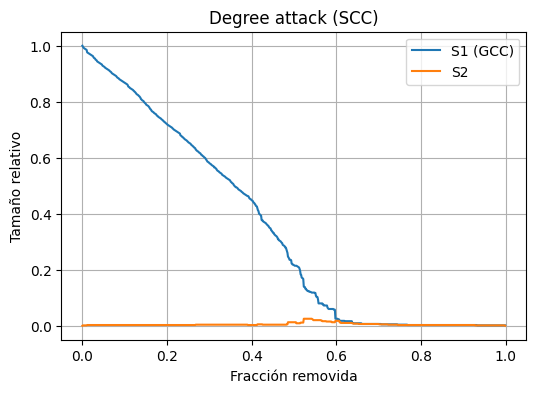

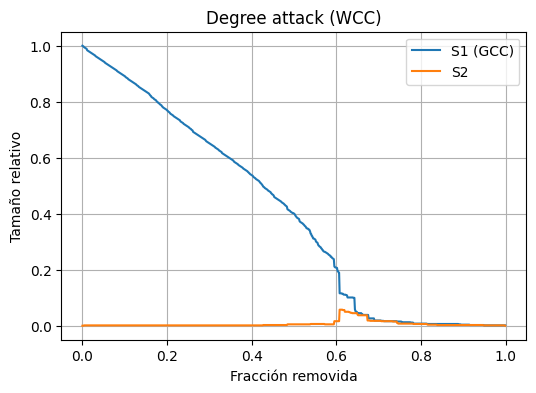

In [34]:
plot_S1_S2(res_deg_strong, "Degree attack (SCC)")
plot_S1_S2(res_deg_weak, "Degree attack (WCC)")

In [35]:
def plot_components(res, title=""):
    plt.figure(figsize=(6,4))
    plt.plot(res["f"], res["n_components"])
    plt.xlabel("Fracción removida")
    plt.ylabel("Número de componentes")
    plt.title(title)
    plt.grid()
    plt.show()

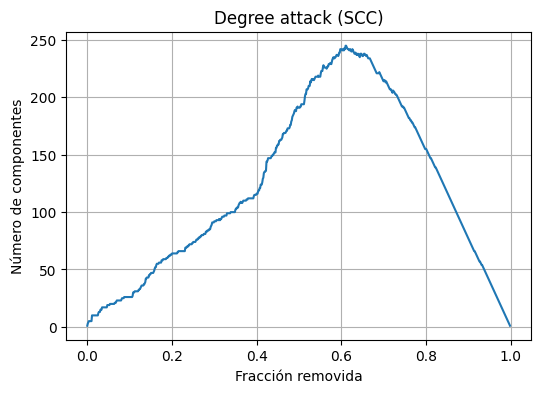

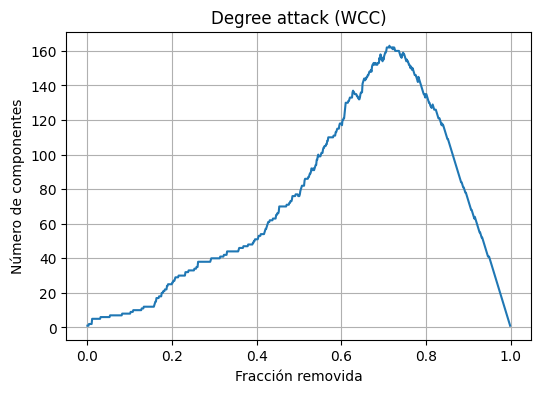

In [36]:
plot_components(res_deg_strong, "Degree attack (SCC)")
plot_components(res_deg_weak, "Degree attack (WCC)")

In [37]:
def plot_mean_rest(res, title=""):
    plt.figure(figsize=(6,4))
    plt.plot(res["f"], res["mean_rest"])
    plt.xlabel("Fracción removida")
    plt.ylabel("Tamaño medio (sin GCC)")
    plt.title(title)
    plt.grid()
    plt.show()

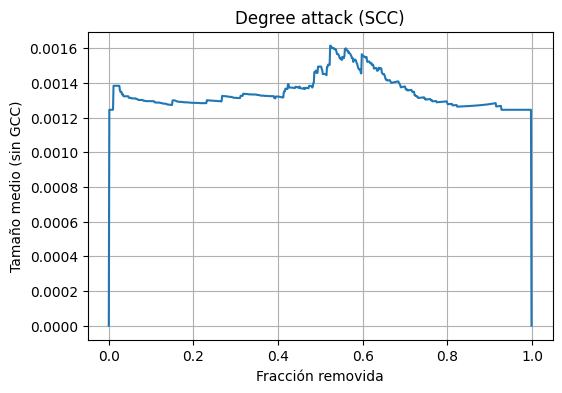

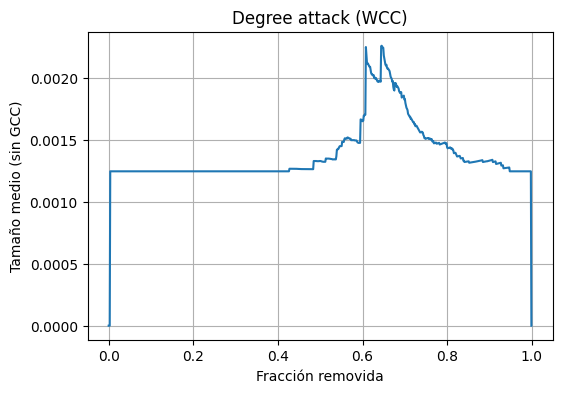

In [38]:
plot_mean_rest(res_deg_strong, "Degree attack (SCC)")
plot_mean_rest(res_deg_weak, "Degree attack (WCC)")

In [39]:
def plot_histogram_step(res, step):
    sizes = res["all_sizes"][step]
    
    plt.figure(figsize=(5,3))
    plt.hist(sizes, bins=20)
    plt.xlabel("Tamaño de componente")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución en paso {step}")
    plt.show()

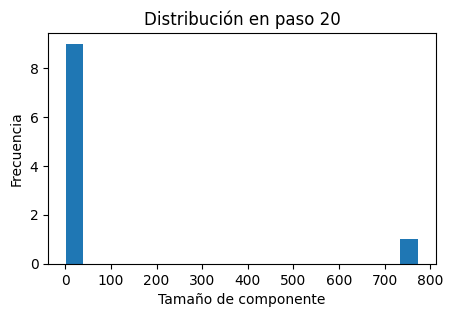

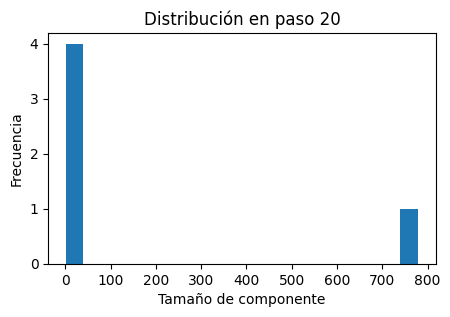

In [40]:
plot_histogram_step(res_deg_strong, 20)
plot_histogram_step(res_deg_weak, 20)

In [41]:
top_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]

print("Top in-degree:")
print(top_in)

print("\nTop out-degree:")
print(top_out)

Top in-degree:
[(160, 211), (62, 178), (107, 168), (121, 156), (86, 153), (434, 150), (183, 142), (129, 136), (64, 135), (128, 131)]

Top out-degree:
[(160, 324), (82, 211), (121, 209), (86, 197), (107, 194), (62, 182), (13, 164), (249, 157), (183, 156), (434, 154)]


In [42]:
set_in = set([n for n, _ in top_in])
set_out = set([n for n, _ in top_out])

print("Intersección:", set_in & set_out)

Intersección: {160, 107, 434, 86, 183, 121, 62}


In [43]:
for n, d in top_in:
    print(f"Nodo {n}: in={G.in_degree(n)}, out={G.out_degree(n)}")

Nodo 160: in=211, out=324
Nodo 62: in=178, out=182
Nodo 107: in=168, out=194
Nodo 121: in=156, out=209
Nodo 86: in=153, out=197
Nodo 434: in=150, out=154
Nodo 183: in=142, out=156
Nodo 129: in=136, out=132
Nodo 64: in=135, out=111
Nodo 128: in=131, out=105


In [44]:
def impact_of_node(G, node):
    G_copy = G.copy()
    N = G.number_of_nodes()

    G_copy.remove_edges_from(list(G_copy.in_edges(node)) + list(G_copy.out_edges(node)))

    largest_cc = max(nx.strongly_connected_components(G_copy), key=len)
    return len(largest_cc) / N


# evaluar top nodos
for n, _ in top_in[:10]:
    print(f"Node {n} impact:", impact_of_node(G, n))

Node 160 impact: 0.9962640099626401
Node 62 impact: 0.9987546699875467
Node 107 impact: 0.9975093399750934
Node 121 impact: 0.9975093399750934
Node 86 impact: 0.9987546699875467
Node 434 impact: 0.9987546699875467
Node 183 impact: 0.9987546699875467
Node 129 impact: 0.9987546699875467
Node 64 impact: 0.9987546699875467
Node 128 impact: 0.9987546699875467


In [45]:
for n, _ in top_in[:5]:
    print(f"[IN] Node {n} impact:", impact_of_node(G, n))

for n, _ in top_out[:5]:
    print(f"[OUT] Node {n} impact:", impact_of_node(G, n))

[IN] Node 160 impact: 0.9962640099626401
[IN] Node 62 impact: 0.9987546699875467
[IN] Node 107 impact: 0.9975093399750934
[IN] Node 121 impact: 0.9975093399750934
[IN] Node 86 impact: 0.9987546699875467
[OUT] Node 160 impact: 0.9962640099626401
[OUT] Node 82 impact: 0.9987546699875467
[OUT] Node 121 impact: 0.9975093399750934
[OUT] Node 86 impact: 0.9987546699875467
[OUT] Node 107 impact: 0.9975093399750934
